<a href="https://colab.research.google.com/github/Ken89MathCompSci/MATNilm-master/blob/kengoh-adamw-weight-decay/2-March-2026-MATNILM-KL-Loss-AdamW-Decay-Model-Results-With-Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pwd

'/content'

In [2]:
cd MATNilm-master/

/content/MATNilm-master


In [3]:


!python main.py --epochs 80 --patience 20 --subName run80epochs

2026-03-02 06:15:38,837 - root - INFO - Using computation device: cuda:0
2026-03-02 06:15:38,837 - root - INFO - Namespace(batch=32, lr=0.001, dropout=0.1, hidden=32, logname='root', subName='run80epochs', inputLength=864, outputLength=864, debug=False, dataAug=False, prob0=0.3, prob1=0.6, prob2=0.3, prob3=0.3, epochs=80, patience=20, resume=False, checkpoint='All_best_onoff.ckpt')
2026-03-02 06:15:38,837 - root - INFO - loading data
2026-03-02 06:15:38,874 - root - INFO - loading data finished
2026-03-02 06:15:38,878 - root - INFO - Training size: 27937.
2026-03-02 06:15:38,878 - root - INFO - Initialize model
2026-03-02 06:15:39,127 - root - INFO - Model MAT
2026-03-02 06:15:43,956 - root - INFO - Training start
2026-03-02 06:15:43,956 - root - INFO - # of epoches: 0
  0% 0/874 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be 

Reading log file: /content/MATNilm-master/log/run80epochs/rootlog_2026_03_02.log
Saved plot: MAE_run20epochs.png


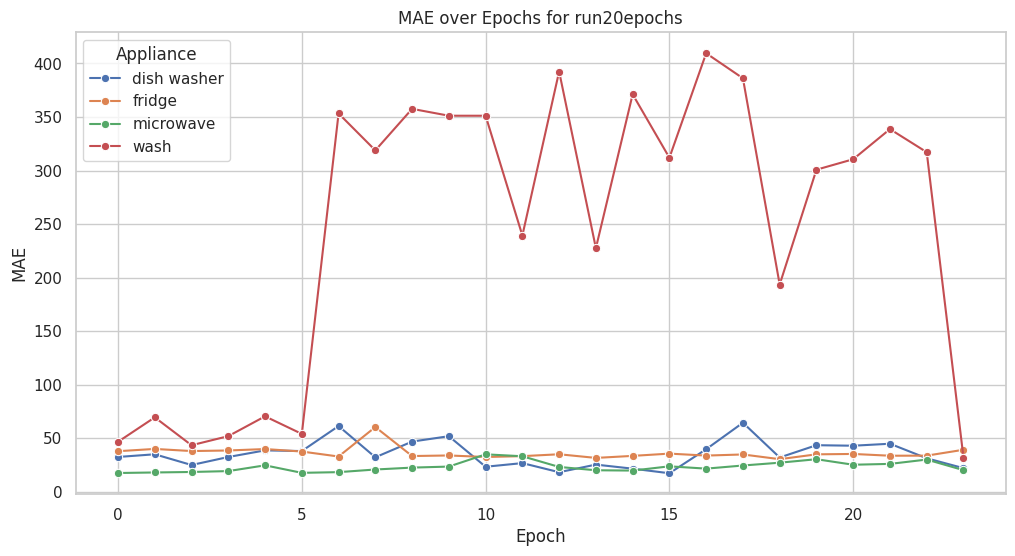

Saved plot: SAE_run20epochs.png


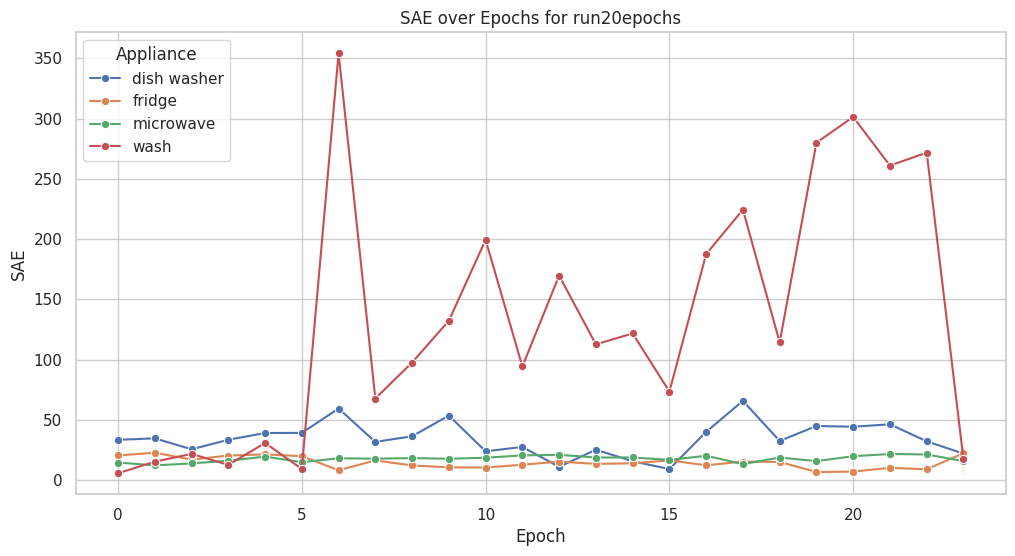

Saved plot: F1_run20epochs.png


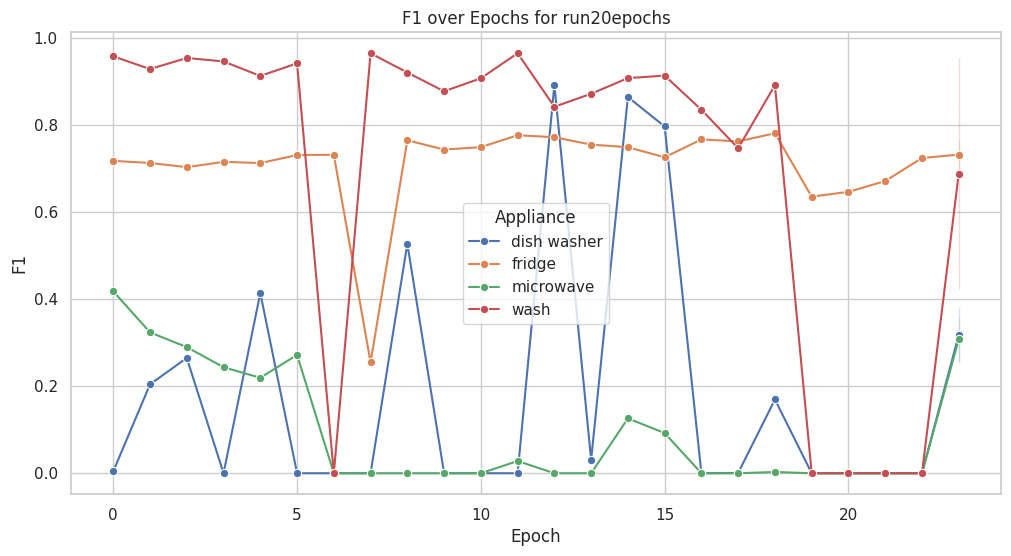

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Find the full path of the log file
log_filename = 'rootlog_2026_03_02.log'
log_path = None
for root, dirs, files in os.walk('/content/MATNilm-master'):
    if log_filename in files:
        log_path = os.path.join(root, log_filename)
        break

if log_path:
    print(f"Reading log file: {log_path}")
    with open(log_path, 'r') as f:
        log_content = f.read()

    # Use the same parsing logic as before
    data = []
    current_epoch = -1
    current_appliance = None

    lines = log_content.split('\n')
    for line in lines:
        epoch_match = re.search(r'Epoch (\d+),', line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))

        appliance_match = re.search(r'Evaluate (.+):', line)
        if appliance_match:
            current_appliance = appliance_match.group(1)

        mae_match = re.search(r'MAE: (\d+\.\d+)', line)
        sae_match = re.search(r'SAE: (\d+\.\d+)', line)
        f1_match = re.search(r'F1: (\d+\.\d+)', line)

        if current_epoch != -1 and current_appliance:
            if mae_match:
                data.append({'epoch': current_epoch, 'appliance': current_appliance, 'metric': 'MAE', 'value': float(mae_match.group(1))})
            elif sae_match:
                data.append({'epoch': current_epoch, 'appliance': current_appliance, 'metric': 'SAE', 'value': float(sae_match.group(1))})
            elif f1_match:
                data.append({'epoch': current_epoch, 'appliance': current_appliance, 'metric': 'F1', 'value': float(f1_match.group(1))})

    if data:
        df_metrics_run = pd.DataFrame(data)

        # Plotting
        sns.set_theme(style="whitegrid")
        metrics = df_metrics_run['metric'].unique()

        for metric in metrics:
            plt.figure(figsize=(12, 6))
            subset_df = df_metrics_run[df_metrics_run['metric'] == metric]
            sns.lineplot(data=subset_df, x='epoch', y='value', hue='appliance', marker='o')
            plt.title(f'{metric} over Epochs for run20epochs')
            plt.xlabel('Epoch')
            plt.ylabel(metric)
            plt.legend(title='Appliance')
            plt.grid(True)

            # Save the plot
            filename = f"{metric}_run20epochs.png"
            plt.savefig(filename)
            print(f"Saved plot: {filename}")

            plt.show()
    else:
        print("No metrics found in the log file.")
else:
    print(f"Log file {log_filename} not found.")